# Tutorial de Clustering K-Means

Clusteringul K-Means este un algoritm de invatare automata nesupervizata folosit pentru a grupa punctele de date in clustere bazate pe similaritatea lor. Este utilizat pe scara larga in mineritul de date, segmentarea imaginilor si recunoasterea de tipare.

## 1. Teorie si Definitii

### Ce este Clusteringul K-Means?

K-Means este un algoritm iterativ care imparte un set de date in `K` clustere, unde fiecare punct de date apartine clusterului cu media (centroidul) cea mai apropiata. Algoritmul minimizeaza **suma patratelor din interiorul clusterului (WCSS)**, care este suma distantelor patrate intre punctele de date si centroidul clusterului lor.

### Pasi ai Algoritmului K-Means:

1. **Initializare**: Selecteaza aleatoriu `K` puncte de date ca centroizi initiali.

2. **Atribuire**: Atribuie fiecare punct de date centroidului cel mai apropiat.

3. **Actualizare**: Recalculeaza centroizii ca media tuturor punctelor de date atribuite fiecarui cluster.

4. **Repetare**: Repeta pasii 2 si 3 pana la convergenta (centroizii nu se mai schimba).

### Concepte Cheie:

- **Centroid**: Media tuturor punctelor dintr-un cluster.

- **WCSS (Within-Cluster Sum of Squares)**: O masura a compactitatii clusterului.

- **Convergenta**: Cand centroizii nu se mai schimba semnificativ.

## 2. Implementare de la Zero

Sa implementam Clusteringul K-Means de la zero folosind NumPy.

In [7]:
import numpy as np
import matplotlib.pyplot as plt

class KMeans:
    def __init__(self, k=3, max_iters=100):
        self.k = k  # Numarul de clustere
        self.max_iters = max_iters  # Numarul maxim de iteratii

    def fit(self, X):
        # Pasul 1: Initializare centroizi aleatoriu
        self.centroids = X[np.random.choice(X.shape[0], self.k, replace=False)]

        for _ in range(self.max_iters):
            # Pasul 2: Atribuire fiecarui punct de date centroidului cel mai apropiat
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            # Pasul 3: Actualizare centroizi
            new_centroids = np.array([X[self.labels == i].mean(axis=0) for i in range(self.k)])

            # Verificare convergenta
            if np.allclose(self.centroids, new_centroids):
                break

            self.centroids = new_centroids

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

### Exemplu de Utilizare

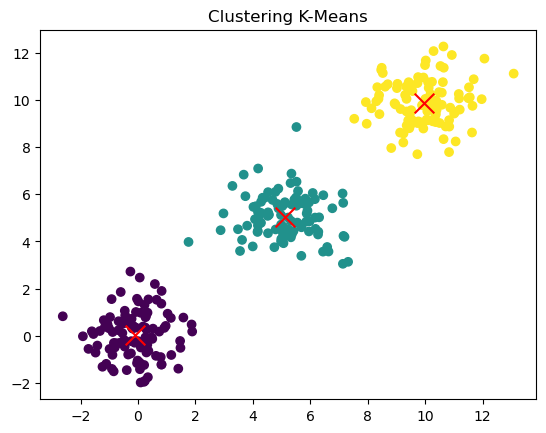

In [8]:
# Generare date de exemplu
np.random.seed(42)
X = np.vstack([
    np.random.normal(loc=[0, 0], scale=1, size=(100, 2)),
    np.random.normal(loc=[5, 5], scale=1, size=(100, 2)),
    np.random.normal(loc=[10, 10], scale=1, size=(100, 2))
])

# Aplicare K-Means
kmeans = KMeans(k=3)
kmeans.fit(X)

# Vizualizare clustere
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels, cmap='viridis')
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1], c='red', marker='x', s=200)
plt.title('Clustering K-Means')
plt.show()

## 3. Exercitii

### Exercitiul 1: Implementare K-Means pe un Set de Date Nou

Genereaza un set de date cu 4 clustere folosind urmatorul cod si aplica Clusteringul K-Means:

In [9]:
np.random.seed(123)
X = np.vstack([
    np.random.normal(loc=[0, 0], scale=1, size=(100, 2)),
    np.random.normal(loc=[5, 5], scale=1, size=(100, 2)),
    np.random.normal(loc=[10, 10], scale=1, size=(100, 2)),
    np.random.normal(loc=[15, 15], scale=1, size=(100, 2))
])

### Exercitiul 2: Vizualizare Clustere

Vizualizeaza clusterele si centroizii dupa rularea K-Means pe setul de date din Exercitiul 1.

### Exercitiul 3: Calcul WCSS

Modifica implementarea K-Means pentru a calcula **Within-Cluster Sum of Squares (WCSS)** si reprezenta-l grafic pentru diferite valori ale lui `K` (de la 1 la 10). Acest lucru este util pentru determinarea numarului optim de clustere folosind **Metoda Cotului**.

In [10]:
def calculate_wcss(X, labels, centroids):
    wcss = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        wcss += np.sum((cluster_points - centroids[i]) ** 2)
    return wcss

wcss_to_plot = []
for k in range(1,16):
    #Aplicare K-means
    kmeans = KMeans(k=k)
    kmeans.fit(X)
    wcss = calculate_wcss(X, kmeans.labels, kmeans.centroids)

### Exercitiul 4: Comparatie cu Scikit-Learn

Compara implementarea ta cu clasa `KMeans` din Scikit-Learn. Foloseste urmatorul cod pentru a rula K-Means din Scikit-Learn:

/home/cosmin/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


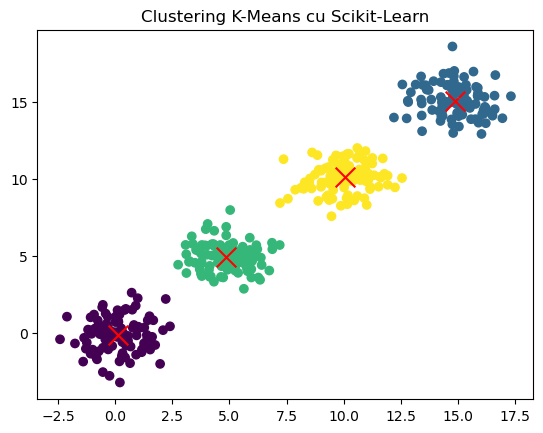

In [12]:
from sklearn.cluster import KMeans as SKLearnKMeans

sklearn_kmeans = SKLearnKMeans(n_clusters=4)
sklearn_kmeans.fit(X)
sklearn_labels = sklearn_kmeans.predict(X)

# Vizualizare rezultate
plt.scatter(X[:, 0], X[:, 1], c=sklearn_labels, cmap='viridis')
plt.scatter(sklearn_kmeans.cluster_centers_[:, 0], sklearn_kmeans.cluster_centers_[:, 1], c='red', marker='x', s=200)
plt.title('Clustering K-Means cu Scikit-Learn')
plt.show()

## 4. Concluzie

In acest tutorial, am invatat despre Clusteringul K-Means, l-am implementat de la zero si l-am aplicat pe un set de date de exemplu. Am explorat, de asemenea, exercitii pentru a consolida intelegerea, inclusiv vizualizarea clusterelor, calculul WCSS si comparatia cu Scikit-Learn.

K-Means este un algoritm puternic si utilizat pe scara larga pentru sarcini de clustering. Cu toate acestea, are limitari, cum ar fi sensibilitatea la centroizii initiali si necesitatea de a specifica numarul de clustere (`K`) in avans. Tehnici precum Metoda Cotului pot ajuta la determinarea valorii optime a lui `K`.